# Titanic Passenger Class Prediction

In this notebook, we predict passenger class (`Pclass`) using machine learning.

This is a multiclass classification problem:

- `1 = First Class`
- `2 = Second Class`
- `3 = Third Class`

Models used:

- Logistic Regression
- Random Forest
- CatBoost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier

## Load the Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/eshummalik/titanic-survival-intelligence-dataset/tested.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## Dataset Overview

We inspect the dataset shape, column types, summary statistics, and missing values.

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (418, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## Feature Engineering

We create new features that may help the models predict passenger class:

- `FamilySize`
- `IsAlone`
- `Title`
- `CabinKnown`

In [6]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)

rare_titles = [
    "Lady", "Countess", "Capt", "Col", "Don", "Dr",
    "Major", "Rev", "Sir", "Jonkheer", "Dona"
]

df["Title"] = df["Title"].replace(rare_titles, "Rare")

df["Title"] = df["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

df["CabinKnown"] = df["Cabin"].notna().astype(int)

df[["FamilySize", "IsAlone", "Title", "CabinKnown"]].head()

,FamilySize,IsAlone,Title,CabinKnown
0,1,1,Mr,0
1,2,0,Mrs,0
2,1,1,Mr,0
3,1,1,Mr,0
4,3,0,Mrs,0


## Define Target and Features

The target variable is `Pclass`.

We remove `Pclass` from the feature set because it is what we are trying to predict.

In [7]:
target = "Pclass"

features = [
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title",
    "CabinKnown"
]

X = df[features]
y = df[target]

## Train-Test Split

We split the data into training and testing sets.

Stratification is used so that the class proportions remain similar in both sets.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (334, 10)
Testing shape: (84, 10)


## Preprocessing Pipeline

Numeric features are imputed with the median and scaled.

Categorical features are imputed with the most frequent value and one-hot encoded.

In [9]:
numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "CabinKnown"
]

categorical_features = [
    "Sex",
    "Embarked",
    "Title"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Define the Models

We compare three machine learning models:

- Logistic Regression
- Random Forest
- CatBoost

In [10]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        iterations=600,
        learning_rate=0.05,
        depth=5,
        loss_function="MultiClass",
        verbose=0,
        random_state=42
    )
}

## Train and Evaluate the Models

Each model is trained using the same preprocessing pipeline.

We evaluate using:

- accuracy
- classification report
- confusion matrix

Logistic Regression
Accuracy: 0.7619

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.81      0.89        21
           2       0.46      0.32      0.38        19
           3       0.76      0.93      0.84        44

    accuracy                           0.76        84
   macro avg       0.74      0.69      0.70        84
weighted avg       0.75      0.76      0.75        84

Confusion Matrix:
[[17  4  0]
 [ 0  6 13]
 [ 0  3 41]]


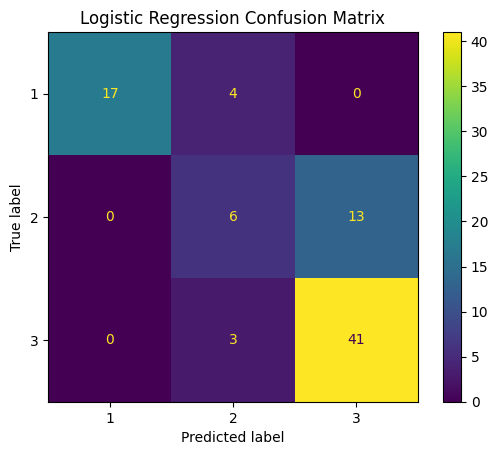

Random Forest
Accuracy: 0.881

Classification Report:
              precision    recall  f1-score   support

           1       0.94      0.81      0.87        21
           2       0.75      0.79      0.77        19
           3       0.91      0.95      0.93        44

    accuracy                           0.88        84
   macro avg       0.87      0.85      0.86        84
weighted avg       0.88      0.88      0.88        84

Confusion Matrix:
[[17  3  1]
 [ 1 15  3]
 [ 0  2 42]]


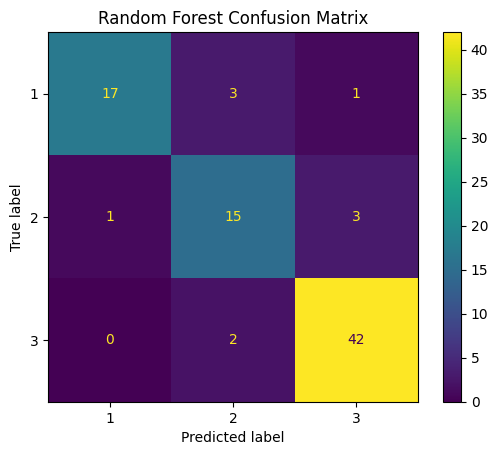

CatBoost
Accuracy: 0.8929

Classification Report:
              precision    recall  f1-score   support

           1       0.95      0.90      0.93        21
           2       0.75      0.79      0.77        19
           3       0.93      0.93      0.93        44

    accuracy                           0.89        84
   macro avg       0.88      0.88      0.88        84
weighted avg       0.90      0.89      0.89        84

Confusion Matrix:
[[19  2  0]
 [ 1 15  3]
 [ 0  3 41]]


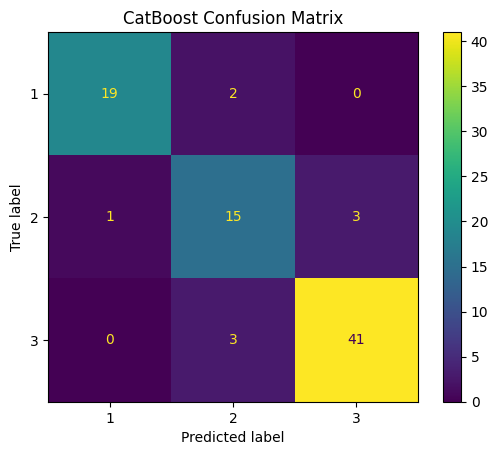

In [11]:
results = []
trained_pipelines = {}

for model_name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy
    })

    trained_pipelines[model_name] = pipe

    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("Accuracy:", round(accuracy, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=[1, 2, 3]
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

## Model Accuracy Comparison

We compare model accuracy on the test set.

In [12]:
results_df = pd.DataFrame(results).sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
2,CatBoost,0.892857
1,Random Forest,0.880952
0,Logistic Regression,0.761905


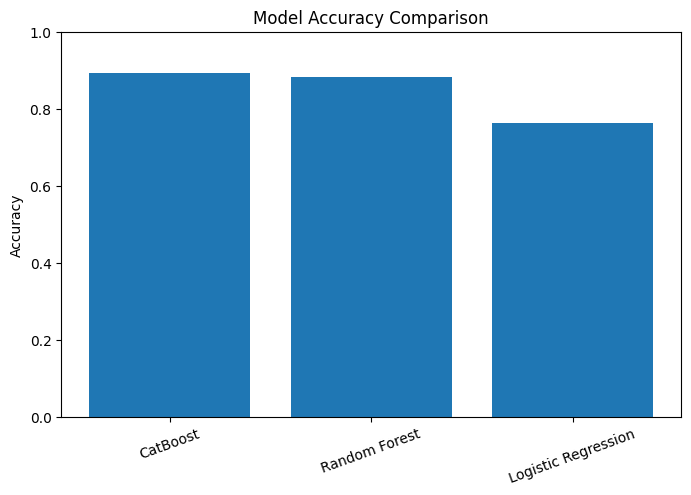

In [13]:
plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.show()

## Cross-Validation

Cross-validation gives a more reliable estimate of model performance than a single train-test split.

In [14]:
cv_results = []

for model_name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    cv_scores = cross_val_score(
        pipe,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_results.append({
        "Model": model_name,
        "CV Mean Accuracy": cv_scores.mean(),
        "CV Std": cv_scores.std()
    })

    print(model_name)
    print("Scores:", np.round(cv_scores, 4))
    print("Mean:", round(cv_scores.mean(), 4))
    print("Std:", round(cv_scores.std(), 4))
    print()

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="CV Mean Accuracy",
    ascending=False
)

cv_results_df

Logistic Regression
Scores: [0.7738 0.7738 0.7738 0.7952 0.7831]
Mean: 0.7799
Std: 0.0084

Random Forest
Scores: [0.9286 0.9167 0.8929 0.9639 0.9157]
Mean: 0.9235
Std: 0.0232

CatBoost
Scores: [0.8929 0.9167 0.8929 0.9759 0.9277]
Mean: 0.9212
Std: 0.0305



,Model,CV Mean Accuracy,CV Std
1,Random Forest,0.923523,0.023244
2,CatBoost,0.921199,0.030535
0,Logistic Regression,0.779948,0.008429


## Random Forest Feature Importance

Feature importance helps us understand which variables contributed most to the Random Forest model.

In [15]:
rf_pipe = trained_pipelines["Random Forest"]

feature_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()

rf_importances = rf_pipe.named_steps["model"].feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False)

rf_importance_df

,Feature,Importance
3,num__Fare,0.493248
0,num__Age,0.143370
6,num__CabinKnown,0.129541
4,num__FamilySize,0.044108
9,cat__Embarked_C,0.028673
11,cat__Embarked_S,0.028663
1,num__SibSp,0.026600
2,num__Parch,0.021371
5,num__IsAlone,0.019808
10,cat__Embarked_Q,0.015825


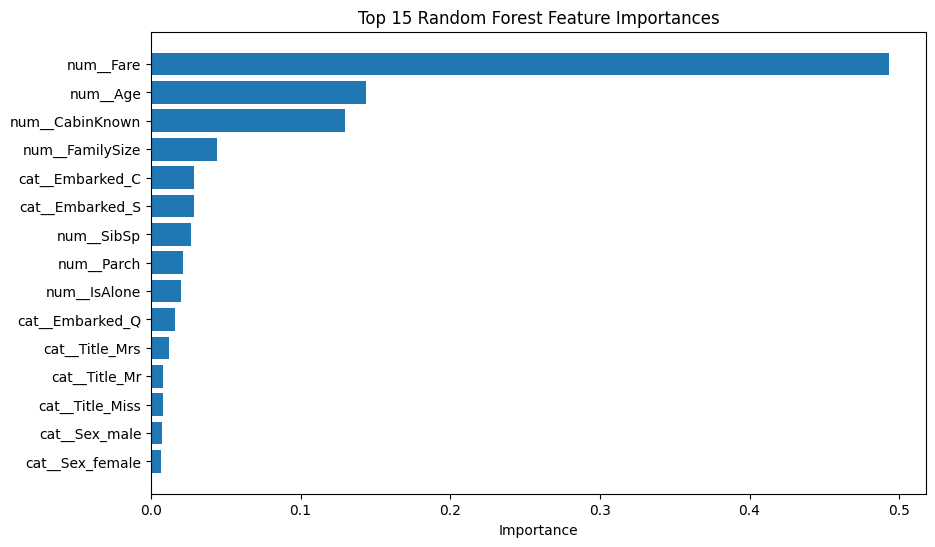

In [16]:
plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance_df["Feature"].head(15)[::-1],
    rf_importance_df["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

## CatBoost Feature Importance

Feature importance helps us understand which variables contributed most to the CatBoost model.

In [17]:
cat_pipe = trained_pipelines["CatBoost"]

cat_feature_names = cat_pipe.named_steps["preprocessor"].get_feature_names_out()

cat_importances = cat_pipe.named_steps["model"].get_feature_importance()

cat_importance_df = pd.DataFrame({
    "Feature": cat_feature_names,
    "Importance": cat_importances
}).sort_values("Importance", ascending=False)

cat_importance_df

,Feature,Importance
3,num__Fare,61.880308
6,num__CabinKnown,8.370825
0,num__Age,7.347077
4,num__FamilySize,6.974729
1,num__SibSp,4.018979
5,num__IsAlone,3.934937
2,num__Parch,2.067663
11,cat__Embarked_S,1.420873
9,cat__Embarked_C,1.239649
14,cat__Title_Mr,0.853318


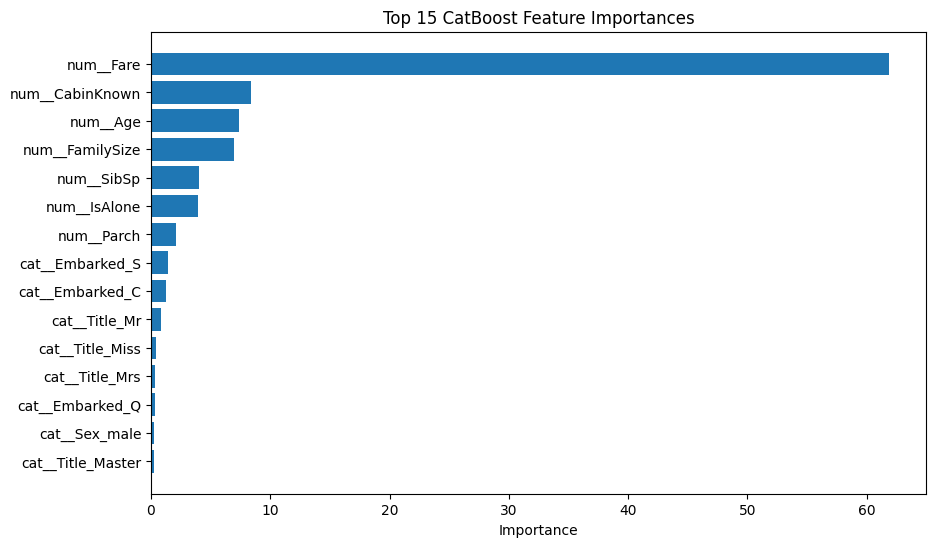

In [18]:
plt.figure(figsize=(10, 6))

plt.barh(
    cat_importance_df["Feature"].head(15)[::-1],
    cat_importance_df["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.title("Top 15 CatBoost Feature Importances")

plt.show()

## Final Conclusions

Random Forest and CatBoost performed much better than Logistic Regression.

Although CatBoost achieved the highest test accuracy in this run, Random Forest achieved the strongest cross-validation performance.

The most important feature was `Fare`, which makes sense because ticket price is strongly related to passenger class.

Other useful features included:

- `CabinKnown`
- `Age`
- `FamilySize`
- `SibSp`
- `Embarked`

Second-class passengers were the most difficult group to classify, likely because their profiles overlap with both first- and third-class passengers.